# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



## LEARNING OBJECTIVES

### 🧠 Conceptual Understanding

- Understand how **GloVe** is based on **co-occurrence statistics**
- Understand the differences between:
  - **One-hot encoding**
  - **Word2Vec (Skip-gram / CBOW)**
  - **GloVe**
- Understand the meaning of a **co-occurrence matrix**
- Understand why **co-occurrence probability ratios** capture semantic meaning

### 💻 Practical Skills

- Build a **co-occurrence matrix**
- Implement a **simplified version of GloVe**
- Train word embeddings on a **small corpus**
- Analyze embeddings using **cosine similarity**




## SHORT THEORY

###Limitation of One-hot Encoding

- Vectors are **very large and sparse**
- Do **not capture semantic meaning**
- Cannot measure **similarity between words**


### Word Embedding

- Words are represented as **dense vectors**:
 king ≈ queen → vector gần nhau

### Co-occurrence Matrix

- Counts how often words appear together within a context window.

**Example**

Sentence: "I love NLP"

Window = 1

→ Co-occurrence matrix:

|     | I | love | NLP |
|-----|---|------|-----|
| I   | 0 | 1    | 0   |
| love| 1 | 0    | 1   |
| NLP | 0 | 1    | 0   |


### Core Idea of GloVe

> 💡 GloVe does not only count co-occurrences — it leverages **ratios of co-occurrence probabilities**

Example:

$$
\frac{P(\text{solid} \mid \text{ice})}{P(\text{solid} \mid \text{steam})}
$$

→ Helps distinguish semantic meaning.


### Loss Function (Simplified)

$$
J = \sum_{i,j} f(X_{ij}) \left( w_i^T w_j + b_i + b_j - \log X_{ij} \right)^2
$$

Where:

- $X_{ij}$: co-occurrence count between word $i$ and $j$  
- $w_i$: word vector  
- $b_i$: bias term  
- $f(x)$: weighting function  

> 💡 The model learns embeddings such that dot products approximate **log co-occurrence counts**.

### GloVe vs Word2Vec

| Aspect | GloVe | Skip-gram (Word2Vec) |
|--------|------|----------------------|
| Data | Global statistics | Local context |
| Input | Co-occurrence matrix | Context window |
| Training | Batch | Online |


> 🎯 Summary:
>
> - **Word2Vec** learns from predicting context  
> - **GloVe** learns from global co-occurrence structure

paper: [GloVe: global vectors for word representation](https://aclanthology.org/D14-1162.pdf)

## Conditional Probability

$$
P(j \mid i) = \frac{X_{ij}}{X_i}
$$

where:

$$
X_i = \sum_k X_{ik}
$$

## Key Insight

Instead of directly using \( P(j \mid i) \), we consider the ratio:

$$
\frac{P(k \mid i)}{P(k \mid j)}
$$

###  Interpretation:

- ( > 1 ): word ( k ) is closer to ( i )  
- ( < 1 ): word ( k ) is closer to ( j )  
- ( \approx 1 ): word ( k ) is neutral  

👉 This ratio captures **semantic meaning**

## Mapping to Vector Space

We want a function:

$$
F(w_i, w_j, w_k) = \frac{P(k \mid i)}{P(k \mid j)}
$$

### Choose a functional form:

$$
F = \exp \left( (w_i - w_j)^T w_k \right)
$$


## Take Logarithm

$$
(w_i - w_j)^T w_k = \log \frac{P(k \mid i)}{P(k \mid j)}
$$

## Expand

$$
w_i^T w_k - w_j^T w_k = \log P(k \mid i) - \log P(k \mid j)
$$


## Key Relationship
$$
w_i^T w_k \approx \log P(k \mid i)
$$

## Replace Probability with Counts
$$
P(k \mid i) = \frac{X_{ik}}{X_i}
$$

Taking log:
$$
\log P(k \mid i) = \log X_{ik} - \log X_i
$$


##  Substitute Back

$$
w_i^T w_k \approx \log X_{ik} - \log X_i
$$

## Handle ( $\log X_i $)

- Depends only on ( i )  
- Does not need to be learned explicitly  

Absorb into bias term:

$$
b_i = -\log X_i
$$

## Final Equation (GloVe)

$$
w_i^T w_j + b_i + b_j \approx \log X_{ij}
$$


### 🚀 Key Takeaway

> GloVe learns word vectors such that their dot product approximates  
> the **log of co-occurrence counts**.

#Code Sample

## Dataset

In [ ]:
corpus = [
    "I love natural language processing",
    "I love deep learning",
    "natural language processing is fun",
    "deep learning is powerful",
    "machine learning is interesting",
    "I enjoy studying machine learning",
    "deep neural networks are powerful",
    "natural language processing is important",
    "I love studying artificial intelligence",
    "artificial intelligence is the future",
    "deep learning models are effective",
    "machine learning models are useful",
    "natural language processing helps understanding text",
    "deep learning is used in computer vision",
    "I enjoy learning about neural networks",
    "AI is transforming the world",
    "data science and machine learning are related",
    "neural networks learn representations",
    "deep learning requires large data",
    "natural language processing is a part of AI"
]

tokens = [sentence.lower().split() for sentence in corpus]


vocab = set()
for sentence in tokens:
    vocab.update(sentence)

vocab = list(vocab)

word_to_idx = {w:i for i,w in enumerate(vocab)}
idx_to_word = {i:w for w,i in word_to_idx.items()}

vocab_size = len(vocab)

## BUILD CO-OCCURRENCE MATRIX

### Context window

In [ ]:
window_size = 2

### Build matrix

In [ ]:
import numpy as np

co_matrix = np.zeros((vocab_size, vocab_size))

for sentence in tokens:
    for i, word in enumerate(sentence):
        word_idx = word_to_idx[word]

        for j in range(-window_size, window_size+1):
            if j == 0:
                continue

            if 0 <= i+j < len(sentence):
                context_word = sentence[i+j]
                context_idx = word_to_idx[context_word]

                co_matrix[word_idx][context_idx] += 1

In [ ]:
co_matrix

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Distance weighting (optional)

In [ ]:
distance = abs(j)
co_matrix[word_idx][context_idx] += 1 / distance

## IMPLEMENT GLOVE (SIMPLIFIED)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class GloVe(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()

        self.wi = nn.Embedding(vocab_size, embed_dim)
        self.wj = nn.Embedding(vocab_size, embed_dim)

        self.bi = nn.Embedding(vocab_size, 1)
        self.bj = nn.Embedding(vocab_size, 1)

    def forward(self, i, j):

        wi = self.wi(i)
        wj = self.wj(j)

        bi = self.bi(i).squeeze()
        bj = self.bj(j).squeeze()

        dot = (wi * wj).sum(dim=1)

        return dot + bi + bj

In [ ]:
def weighting(x, x_max=100, alpha=0.75):
    return (x / x_max) ** alpha if x < x_max else 1

## TRAINING

In [ ]:
pairs = []

for i in range(vocab_size):
    for j in range(vocab_size):
        if co_matrix[i][j] > 0:
            pairs.append((i, j, co_matrix[i][j]))

In [ ]:
model = GloVe(vocab_size, embed_dim=10)
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200

for epoch in range(epochs):
    total_loss = 0

    for i, j, x in pairs:

        i = torch.tensor([i])
        j = torch.tensor([j])
        x = torch.tensor([x], dtype=torch.float)

        pred = model(i, j)

        log_x = torch.log(x)

        weight = weighting(x.item())

        loss = weight * (pred - log_x) ** 2

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 128.43416943706234
Epoch: 20 Loss: 2.4152057653986674
Epoch: 40 Loss: 1.988502842380008
Epoch: 60 Loss: 0.8000820291600377
Epoch: 80 Loss: 0.7268468788596181
Epoch: 100 Loss: 0.5927576327661895
Epoch: 120 Loss: 0.5086749722553225
Epoch: 140 Loss: 0.45903961153991446
Epoch: 160 Loss: 0.31358574736698586
Epoch: 180 Loss: 0.4074219371953518


## ANALYSIS / VISUALIZATION

### Cosine similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

embeddings = model.wi.weight.data

def most_similar(word, top_k=5):
    idx = word_to_idx[word]
    vec = embeddings[idx].unsqueeze(0)

    sims = cosine_similarity(vec, embeddings)[0]

    top_idx = sims.argsort()[-top_k:]

    for i in top_idx:
        print(idx_to_word[i])

In [ ]:
most_similar("learning")

fun
useful
about
powerful
learning


### PCA visualization

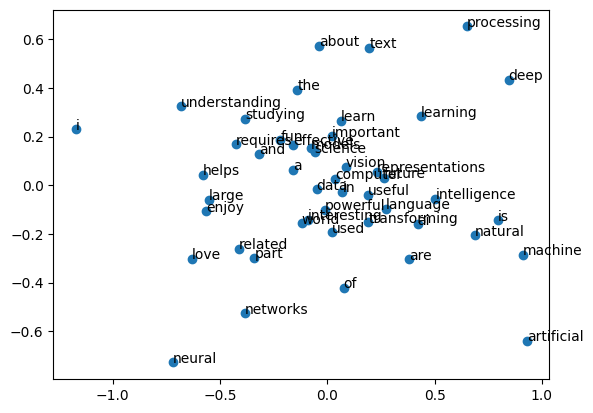

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.scatter(reduced[:,0], reduced[:,1])

for i, word in enumerate(vocab):
    plt.annotate(word, (reduced[i,0], reduced[i,1]))

plt.show()

 # Homewwork

## 💬 Discussion Questions

1️⃣ Why is co-occurrence important?

2️⃣ Why is a weighting function needed?

3️⃣ How do rare words affect the model?

4️⃣ Why is GloVe considered a “global” model?

5️⃣ When does GloVe perform better than Word2Vec?

## 🧪 Experiments & Exercises



In [ ]:
from datasets import load_dataset

dataset = load_dataset("VTSNLP/vietnamese_curated_dataset",split="train",streaming = True)
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

IterableDataset({
    features: ['text', 'id', 'domain'],
    num_shards: 132
})


## 🧪 LAB PIPELINE: GloVe Implementation

---

### PART 1 — DATA PREPROCESSING

#### ✅ Requirements

- Extract text:

```python
texts = [item['text'] for item in dataset]
```

Clean the data:
- Convert to lowercase
- Remove special characters
- Remove numbers

Tokenization:
```python
from underthesea import word_tokenize
```

Questions
- What kinds of noise exist in web data?
- What makes Vietnamese tokenization challenging?

### PART 2 — VOCABULARY
####✅ Requirements
Limit vocabulary size:
```python
max_vocab = 10000
Remove low-frequency words:
min_freq = 5
```
Questions

How does a larger vocabulary affect:
- Memory usage?
- Training time?

### PART 3 — CO-OCCURRENCE MATRIX
#### ✅ Requirements
Build the co-occurrence matrix with:
- window_size = 2 / 5
- Apply distance weighting:
  - weight = 1 / distance

Analysis
- How does a larger window size change the matrix?
- Why is weighting by distance important?

### PART 4 — IMPLEMENT GLOVE
#### ✅ Requirements

Implement all components:
- Word vectors
- Context vectors
- Bias terms
- Weighting function

🧪 Experiments
Change:
- embedding_dim = 50 / 100

### PART 5 — TRAINING
#### ✅ Requirements
- Train for at least 50–100 epochs
- Log the training loss

🎯 Analysis
- Does the loss decrease over time?
- Does it plateau?

### PART 6 — WORD SIMILARITY (IMPORTANT)
#### ✅ Requirements

Implement and test:
- most_similar("học")
- most_similar("công_nghệ")
- most_similar("việt_nam")

🎯 Analysis
- Do the results show semantic meaning?
- Are there any noisy or irrelevant words?

### PART 7 — VISUALIZATION
#### ✅ Requirements
- Use PCA or t-SNE
- Visualize ~100 frequent words

🎯 Questions
- Do similar words form clusters?
- Are different topics well separated?

### PART 8 — COMPARISON (IMPORTANT)
Students write a report comparing:
- Metric	GloVe	Skip-gram
- Speed
- Quality
- Stability